<a href="https://colab.research.google.com/github/jayanthkorupolu2000-web/Final_Project/blob/main/Fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Vision Transformer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'patch_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Building Attention CNN...
Loading Attention CNN weights...
Loading Hybrid EfficientNetV2...
All models ready!

Upload a test image


Saving 20140704_180951-1-1-_jpg.rf.97ea7191d2736775411a5872a11a5c16.jpg.jpeg to 20140704_180951-1-1-_jpg.rf.97ea7191d2736775411a5872a11a5c16.jpg.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 945ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

Model Predictions
Vision Transformer : 0.416
Attention CNN      : 0.757
EfficientNetV2     : 0.837

Dynamic Weights
ViT Weight : 0.124
CNN Weight : 0.379
Eff Weight : 0.496

Final Fusion Probability : 0.754

FINAL RESULT : CRACK DETECTED


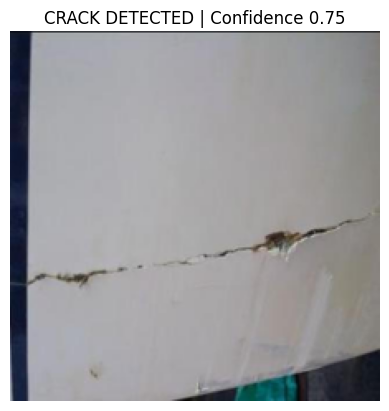

In [4]:
# ==========================================
# CRACK DETECTION USING 3-MODEL FUSION
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras import layers, models

IMG_SIZE = 224

# ==========================================
# PATCH EMBEDDING FOR ViT
# ==========================================

PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
EMBED_DIM = 64

class PatchEmbedding(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.proj = layers.Conv2D(EMBED_DIM, PATCH_SIZE, PATCH_SIZE)
        self.flatten = layers.Reshape((NUM_PATCHES, EMBED_DIM))

    def call(self, x):
        x = self.proj(x)
        return self.flatten(x)


# ==========================================
# CBAM ATTENTION BLOCK
# ==========================================

def cbam_block(x):

    channels = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    dense1 = layers.Dense(channels//8, activation="relu")
    dense2 = layers.Dense(channels)

    avg_out = dense2(dense1(avg_pool))
    max_out = dense2(dense1(max_pool))

    channel = layers.Activation("sigmoid")(layers.Add()([avg_out, max_out]))
    channel = layers.Reshape((1,1,channels))(channel)

    x = layers.Multiply()([x, channel])

    avg_pool = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True))(x)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    spatial = layers.Conv2D(1,7,padding="same",activation="sigmoid")(concat)

    x = layers.Multiply()([x, spatial])

    return x


# ==========================================
# ATTENTION CNN MODEL (MATCHES TRAINING)
# ==========================================

def build_attention_cnn():

    inputs = layers.Input(shape=(224,224,3))

    x = layers.Conv2D(32,3,padding="same",activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64,3,padding="same",activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128,3,padding="same",activation="relu")(x)
    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)

    # IMPORTANT: match trained architecture
    x = layers.Dense(128,activation="relu")(x)

    outputs = layers.Dense(1,activation="sigmoid")(x)

    return models.Model(inputs,outputs)


# ==========================================
# LOAD MODELS
# ==========================================

print("Loading Vision Transformer...")
vit_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/vit_model.keras",
    custom_objects={"PatchEmbedding": PatchEmbedding},
    compile=False
)

print("Building Attention CNN...")
attn_model = build_attention_cnn()

print("Loading Attention CNN weights...")
attn_model.load_weights("/content/drive/MyDrive/attn_cnn_model.keras")

print("Loading Hybrid EfficientNetV2...")
hybrid_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/hybrid_finetuned_model.keras",
    compile=False
)

print("All models ready!")


# ==========================================
# IMAGE PREPROCESSING
# ==========================================

def preprocess_image(image_path):

    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img_array = np.array(img)/255.0
    img_array = img_array.astype(np.float32)

    img_array = np.expand_dims(img_array, axis=0)

    return img_array, img


# ==========================================
# DYNAMIC CONFIDENCE FUSION
# ==========================================

def dynamic_confidence_fusion(p_vit, p_cnn, p_eff):

    c_vit = abs(p_vit - 0.5)
    c_cnn = abs(p_cnn - 0.5)
    c_eff = abs(p_eff - 0.5)

    total = c_vit + c_cnn + c_eff

    w_vit = c_vit / total
    w_cnn = c_cnn / total
    w_eff = c_eff / total

    p_final = (w_vit*p_vit) + (w_cnn*p_cnn) + (w_eff*p_eff)

    return p_final, w_vit, w_cnn, w_eff


# ==========================================
# PREDICTION FUNCTION
# ==========================================

def predict_image(image_path):

    img_array, img = preprocess_image(image_path)

    p_vit = float(vit_model.predict(img_array)[0][0])
    p_cnn = float(attn_model.predict(img_array)[0][0])
    p_eff = float(hybrid_model.predict(img_array)[0][0])

    p_final, w_vit, w_cnn, w_eff = dynamic_confidence_fusion(
        p_vit, p_cnn, p_eff
    )

    print("\nModel Predictions")
    print("Vision Transformer :", round(p_vit,3))
    print("Attention CNN      :", round(p_cnn,3))
    print("EfficientNetV2     :", round(p_eff,3))

    print("\nDynamic Weights")
    print("ViT Weight :", round(w_vit,3))
    print("CNN Weight :", round(w_cnn,3))
    print("Eff Weight :", round(w_eff,3))

    print("\nFinal Fusion Probability :", round(p_final,3))

    if p_final > 0.5:
        result = "CRACK DETECTED"
    else:
        result = "NO CRACK"

    print("\nFINAL RESULT :", result)

    plt.imshow(img)
    plt.title(f"{result} | Confidence {round(p_final,2)}")
    plt.axis("off")
    plt.show()


# ==========================================
# UPLOAD IMAGE FROM DESKTOP
# ==========================================

print("\nUpload a test image")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

predict_image(image_path)